# 🧬 Genetic Algorithms: A Visual Introduction
### Inspired by Darwin's Theory of Evolution

Genetic Algorithms (GAs) are search and optimisation techniques modelled on **natural selection**.
Just as evolution favours organisms best suited to their environment, GAs iteratively improve a
population of candidate solutions until a near-optimal answer emerges.

---

## The Problem We'll Solve: Travelling Salesman Problem (TSP)
> *"A salesman must visit every city exactly once and return home.
>  What is the **shortest** possible route?"*

This is a classic *NP-hard* problem — brute-forcing 15 cities would require checking
**15! ≈ 1.3 trillion** routes. GAs find excellent solutions in seconds.

---

## The Five Stages of a Genetic Algorithm

| Stage | Biological Analogy | What happens |
|---|---|---|
| 1️⃣ **Initialisation** | First generation | Create random candidate routes |
| 2️⃣ **Fitness Evaluation** | Survival pressure | Score each route (shorter = fitter) |
| 3️⃣ **Selection** | "Survival of the fittest" | Choose better routes as parents |
| 4️⃣ **Crossover** | Reproduction | Combine two parents into a child |
| 5️⃣ **Mutation** | Random genetic change | Tweak routes to maintain diversity |

Then **repeat** until satisfied with the result!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import random
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFB',
    'grid.alpha':      0.35,
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.titleweight':'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Colour palette ───────────────────────────────────────────────────────────
BLUE   = '#2196F3'
RED    = '#F44336'
GREEN  = '#4CAF50'
ORANGE = '#FF9800'
PURPLE = '#9C27B0'
GOLD   = '#FFC107'
DARK   = '#37474F'

print('✅  All libraries loaded.')
print(f'   numpy      {np.__version__}')
print(f'   matplotlib {plt.matplotlib.__version__}')


✅  All libraries loaded.
   numpy      2.4.2
   matplotlib 3.10.8


In [2]:
# ============================================================
#  Core Genetic Algorithm Functions
# ============================================================

def total_distance(route, cities):
    """Total round-trip distance for a route."""
    n = len(route)
    return sum(
        np.linalg.norm(cities[route[i]] - cities[route[(i + 1) % n]])
        for i in range(n)
    )

def fitness(route, cities):
    """Fitness = 1 / distance  (higher is better)."""
    return 1.0 / total_distance(route, cities)

def create_route(n_cities):
    """Random permutation of city indices."""
    r = list(range(n_cities))
    random.shuffle(r)
    return r

def create_population(pop_size, n_cities):
    """Initialise a random population."""
    return [create_route(n_cities) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=5):
    """Pick k random individuals; return a copy of the fittest."""
    contestants = random.sample(list(range(len(population))), k)
    winner = max(contestants, key=lambda i: fitnesses[i])
    return population[winner][:]

def ordered_crossover(p1, p2):
    """Ordered Crossover (OX-1): inherits a slice from p1,
    fills the rest from p2 in order."""
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = p1[a:b]
    remaining = [c for c in p2 if c not in child[a:b]]
    j = 0
    for i in range(n):
        if child[i] is None:
            child[i] = remaining[j]
            j += 1
    return child

def swap_mutation(route, rate=0.015):
    """Swap two random cities with probability `rate` per gene."""
    route = route[:]
    n = len(route)
    for i in range(n):
        if random.random() < rate:
            j = random.randint(0, n - 1)
            route[i], route[j] = route[j], route[i]
    return route

def run_ga(cities, pop_size=150, generations=300,
           mutation_rate=0.015, tournament_k=5, elite_size=15,
           snapshot_gens=None):
    """Run the full Genetic Algorithm.

    Returns
    -------
    best_route   : list of city indices
    history      : dict with 'best_distances' and 'avg_distances'
    snapshots    : dict {generation: best_route_at_that_gen}
    """
    if snapshot_gens is None:
        snapshot_gens = set()
    else:
        snapshot_gens = set(snapshot_gens)

    n_cities   = len(cities)
    population = create_population(pop_size, n_cities)

    best_distances, avg_distances = [], []
    snapshots = {}
    overall_best, overall_best_dist = None, float('inf')

    for gen in range(generations):
        distances = [total_distance(r, cities) for r in population]
        fitnesses = [1.0 / d for d in distances]

        best_idx = int(np.argmin(distances))
        if distances[best_idx] < overall_best_dist:
            overall_best_dist = distances[best_idx]
            overall_best      = population[best_idx][:]

        best_distances.append(overall_best_dist)
        avg_distances.append(float(np.mean(distances)))

        if gen in snapshot_gens:
            snapshots[gen] = population[best_idx][:]

        # ── Next generation ──────────────────────────────────────────────
        ranked    = sorted(range(pop_size), key=lambda i: distances[i])
        elite     = [population[i][:] for i in ranked[:elite_size]]
        children  = []
        while len(children) < pop_size - elite_size:
            p1    = tournament_selection(population, fitnesses, tournament_k)
            p2    = tournament_selection(population, fitnesses, tournament_k)
            child = ordered_crossover(p1, p2)
            child = swap_mutation(child, mutation_rate)
            children.append(child)

        population = elite + children

    return overall_best, {'best_distances': best_distances,
                          'avg_distances':  avg_distances}, snapshots

print('✅  All GA functions defined.')


✅  All GA functions defined.


## 🗺️  The Problem: 15 Cities, Infinite Possible Routes

With 15 cities there are **15! ≈ 1.3 trillion** possible routes.
We can't check them all — but a Genetic Algorithm can find a great solution fast.


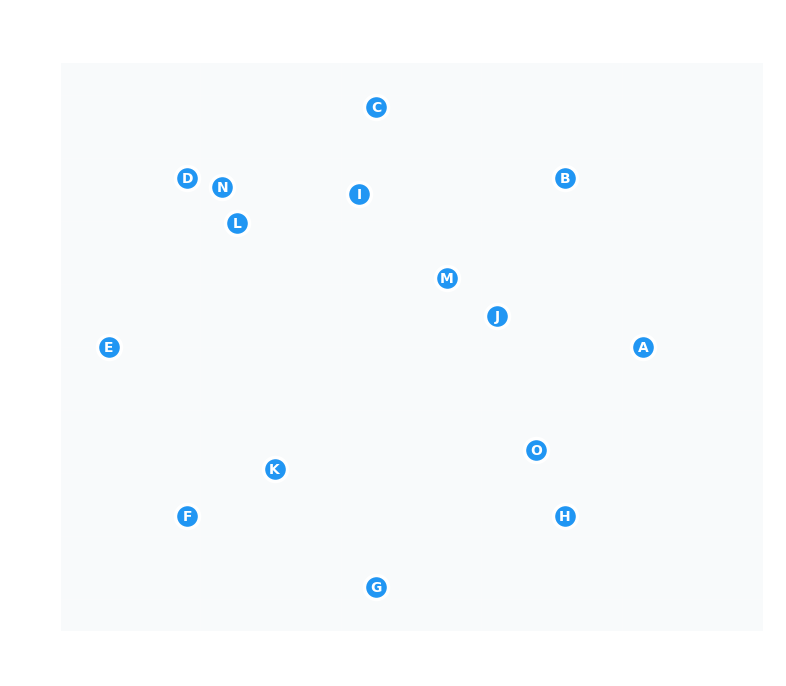

Number of possible routes: 1,307,674,368,000
That would take a long time to check one-by-one...


In [3]:
# ── City layout ─────────────────────────────────────────────────────────────
NUM_CITIES = 15
np.random.seed(SEED)

# A ring of 8 outer cities + 7 inner cities for a visually interesting map
angles      = np.linspace(0, 2 * np.pi, 8, endpoint=False)
outer       = np.column_stack([45 + 38 * np.cos(angles),
                               50 + 38 * np.sin(angles)])
inner       = np.random.rand(7, 2) * 55 + 22
cities      = np.vstack([outer, inner])

CITY_LABELS = [chr(65 + i) for i in range(NUM_CITIES)]   # A, B, C, …

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(cities[:, 0], cities[:, 1],
           s=300, c=BLUE, zorder=5, edgecolors='white', linewidth=2.5)

for i, (x, y) in enumerate(cities):
    ax.annotate(CITY_LABELS[i], (x, y),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=6)

ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
ax.set_title(f'The Travelling Salesman Problem\n'
             f'{NUM_CITIES} cities — find the shortest round-trip!', pad=14)
ax.set_xlabel('X coordinate');  ax.set_ylabel('Y coordinate')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('01_cities.png', dpi=150, bbox_inches='tight')
plt.show()

from math import factorial
print(f'Number of possible routes: {factorial(NUM_CITIES):,}')
print(f'That would take a long time to check one-by-one...')


## Stage 1️⃣ — Initialisation: Create a Random Population

We start by generating a **population** of completely random routes.
Think of these as the very first generation — no knowledge yet, just variety.

**Key insight:** We need *diversity* in the population so evolution has something to work with.


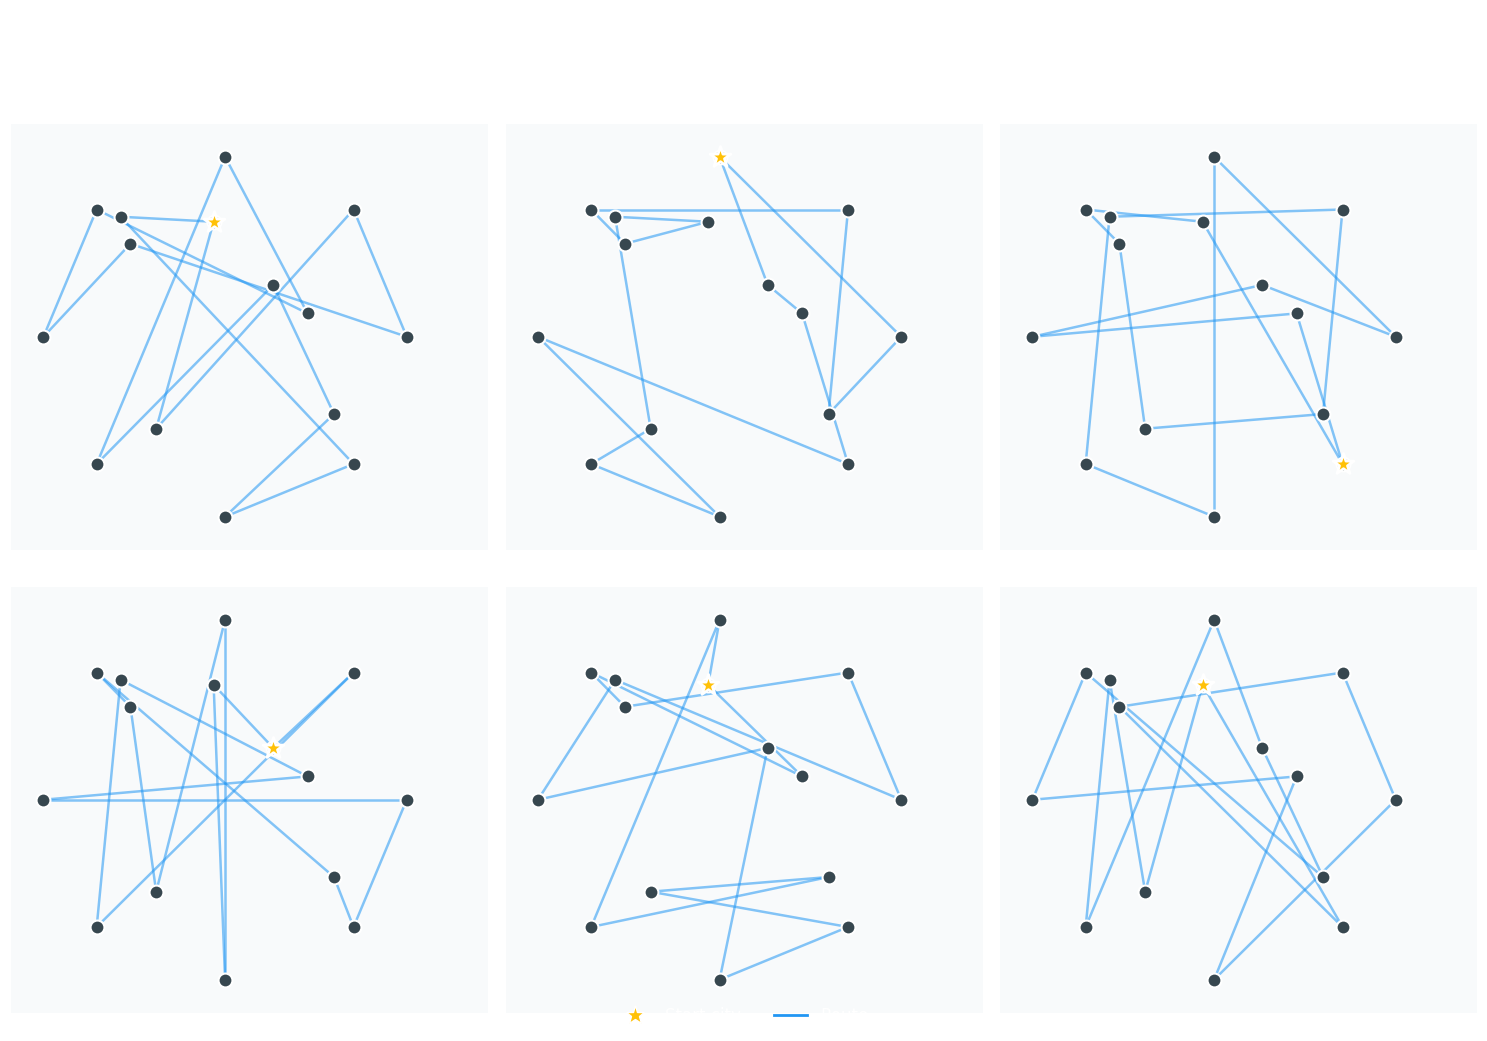

Population of 150 routes created.
Distances range from 505 to 832


In [8]:
# Create initial population of 150 random routes
random.seed(SEED);  np.random.seed(SEED)
population = create_population(150, NUM_CITIES)

# ── Show 6 random routes ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx in range(6):
    ax    = axes[idx]
    route = population[idx]
    dist  = total_distance(route, cities)

    # Draw route edges
    for i in range(NUM_CITIES):
        a, b = cities[route[i]], cities[route[(i + 1) % NUM_CITIES]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=BLUE, alpha=0.55, linewidth=1.8,
                solid_capstyle='round')

    # Cities
    ax.scatter(cities[:, 0], cities[:, 1],
               s=100, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)

    # Start city (gold star)
    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=250, c=GOLD, zorder=6,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'Route #{idx + 1}   |   Distance: {dist:.0f}', fontsize=11)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

leg = [Line2D([0], [0], marker='*', color='w', markerfacecolor=GOLD,
              markersize=14, label='Start city'),
       Line2D([0], [0], color=BLUE, linewidth=2, label='Route')]
fig.legend(handles=leg, loc='lower center', ncol=2, frameon=False,
           fontsize=12, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Stage 1: Initialisation\n'
             '150 random routes created — each visits every city once',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('02_initial_population.png', dpi=150, bbox_inches='tight')
plt.show()

distances_init = [total_distance(r, cities) for r in population]
print(f'Population of {len(population)} routes created.')
print(f'Distances range from {min(distances_init):.0f} to {max(distances_init):.0f}')


## Stage 2️⃣ — Fitness Evaluation: Score Every Route

We need a way to rank solutions. The **fitness function** maps a route to a score:

$$\text{fitness} = \frac{1}{\text{total distance}}$$

Shorter route → higher fitness → more likely to survive and reproduce.


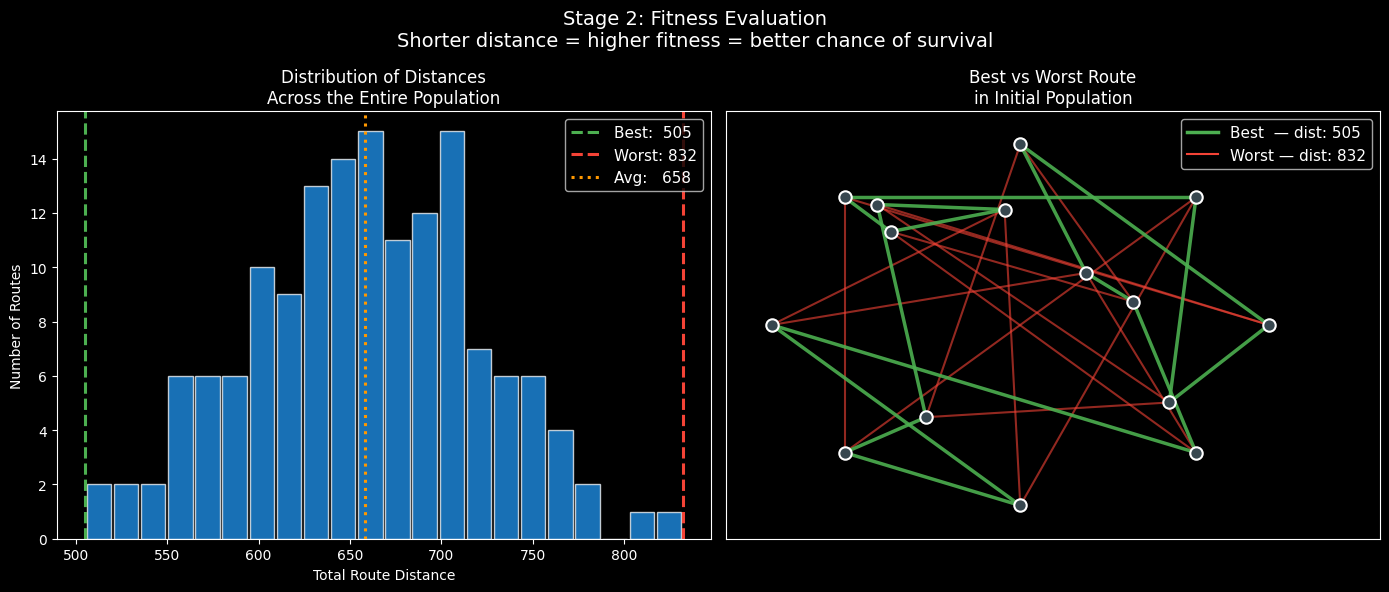

In [19]:
distances_init = [total_distance(r, cities) for r in population]
fitnesses_init = [1.0 / d for d in distances_init]

best_idx  = int(np.argmin(distances_init))
worst_idx = int(np.argmax(distances_init))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Distance histogram ─────────────────────────────────────────────────
ax = axes[0]
ax.hist(distances_init, bins=22, color=BLUE, alpha=0.75, edgecolor='white',
        rwidth=0.9)
ax.axvline(distances_init[best_idx],  color=GREEN,  linewidth=2.2,
           linestyle='--', label=f'Best:  {distances_init[best_idx]:.0f}')
ax.axvline(distances_init[worst_idx], color=RED,    linewidth=2.2,
           linestyle='--', label=f'Worst: {distances_init[worst_idx]:.0f}')
ax.axvline(np.mean(distances_init),   color=ORANGE, linewidth=2.2,
           linestyle=':',  label=f'Avg:   {np.mean(distances_init):.0f}')
ax.set_xlabel('Total Route Distance')
ax.set_ylabel('Number of Routes')
ax.set_title('Distribution of Distances\nAcross the Entire Population')
ax.legend(fontsize=11)

# ── Right: Best vs Worst routes ──────────────────────────────────────────────
ax = axes[1]

def draw_route(ax, route, color, lw=1.8, alpha=0.75):
    n = len(route)
    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=alpha, linewidth=lw,
                solid_capstyle='round')

draw_route(ax, population[worst_idx], RED,   lw=1.5, alpha=0.6)
draw_route(ax, population[best_idx],  GREEN, lw=2.5, alpha=0.9)
ax.scatter(cities[:, 0], cities[:, 1],
           s=80, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)

leg2 = [Line2D([0], [0], color=GREEN, linewidth=2.5,
               label=f'Best  — dist: {distances_init[best_idx]:.0f}'),
        Line2D([0], [0], color=RED,   linewidth=1.5,
               label=f'Worst — dist: {distances_init[worst_idx]:.0f}')]
ax.legend(handles=leg2, fontsize=11)
ax.set_title('Best vs Worst Route\nin Initial Population')
ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
ax.set_xticks([]);    ax.set_yticks([])

fig.suptitle('Stage 2: Fitness Evaluation\n'
             'Shorter distance = higher fitness = better chance of survival',
             fontsize=14)
plt.tight_layout()
plt.savefig('03_fitness_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 3️⃣ — Selection: Survival of the Fittest

We use **Tournament Selection**:
1. Pick 5 random individuals from the population
2. The one with the shortest route **wins** and becomes a parent
3. Repeat to get a second parent

This gives fitter individuals a higher *chance* of reproducing —
but weaker ones aren't completely excluded, preserving diversity.


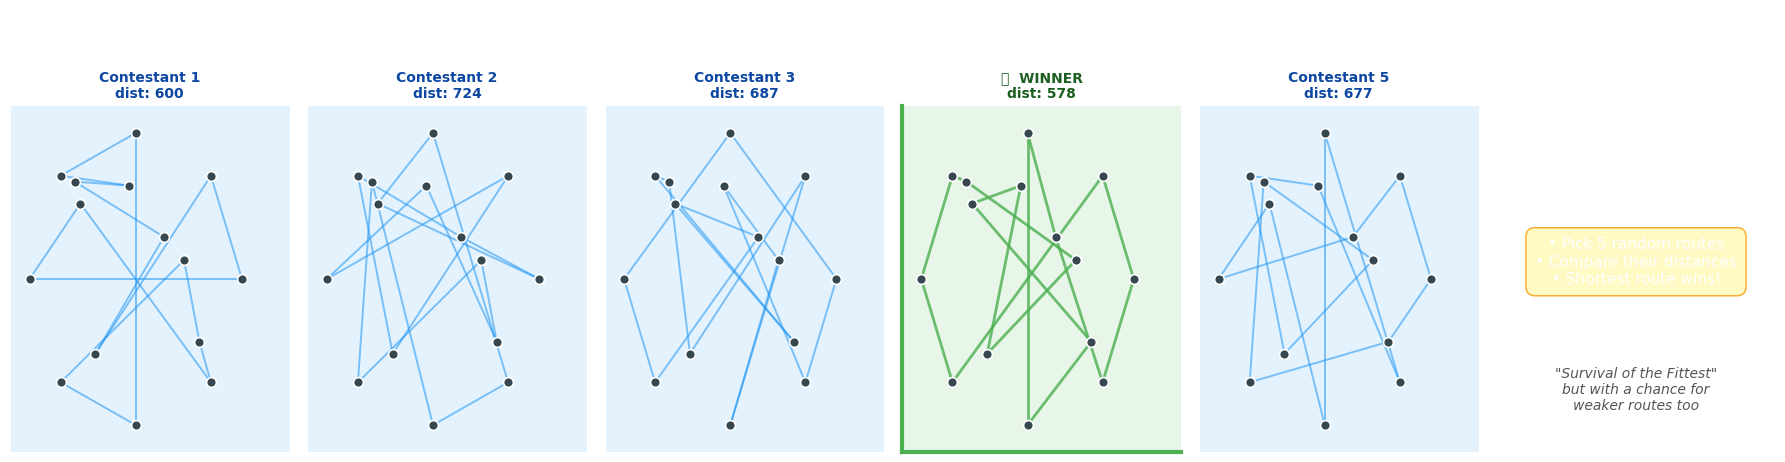

In [10]:
random.seed(7)   # fixed seed so the tournament looks interesting

TOURNAMENT_K = 5
contestants  = random.sample(range(len(population)), TOURNAMENT_K)
t_routes     = [population[i] for i in contestants]
t_distances  = [distances_init[i] for i in contestants]
winner_local = int(np.argmin(t_distances))

fig, axes = plt.subplots(1, TOURNAMENT_K + 1, figsize=(18, 4.5))

for j, (idx, route, dist) in enumerate(zip(contestants, t_routes, t_distances)):
    ax        = axes[j]
    is_winner = (j == winner_local)
    fc        = '#E8F5E9' if is_winner else '#E3F2FD'
    ax.set_facecolor(fc)

    draw_route(ax, route,
               GREEN if is_winner else BLUE,
               lw=2 if is_winner else 1.4,
               alpha=0.8 if is_winner else 0.55)
    ax.scatter(cities[:, 0], cities[:, 1],
               s=50, c=DARK, zorder=5, edgecolors='white', linewidth=1.2)

    title_txt = ('🏆  WINNER\n' if is_winner else f'Contestant {j + 1}\n')
    title_col = '#1B5E20' if is_winner else '#0D47A1'
    ax.set_title(f'{title_txt}dist: {dist:.0f}', color=title_col, fontsize=10)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    if is_winner:
        for spine in ax.spines.values():
            spine.set_edgecolor(GREEN);  spine.set_linewidth(3)

# Explanation panel
ax = axes[-1]
ax.axis('off')
ax.text(0.5, 0.80, 'Tournament\nSelection', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.55,
        f'• Pick {TOURNAMENT_K} random routes\n'
        '• Compare their distances\n'
        '• Shortest route wins!',
        ha='center', va='center', fontsize=11, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.6', fc='#FFF9C4', ec='#F9A825'))
ax.text(0.5, 0.18, '"Survival of the Fittest"\nbut with a chance for\nweaker routes too',
        ha='center', va='center', fontsize=10, style='italic',
        color='#555', transform=ax.transAxes)

fig.suptitle('Stage 3: Selection — Tournament Selection',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('04_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 4️⃣ — Crossover: Combining Two Parents

Standard crossover (e.g., flipping a coin per gene) doesn't work for TSP —
we'd create routes that visit some cities twice and others never.

We use **Ordered Crossover (OX-1)**:
1. Copy a random *slice* from Parent 1 into the child
2. Fill the remaining positions with cities from Parent 2, **in the order they appear**
3. Result: a valid route that inherits structure from both parents


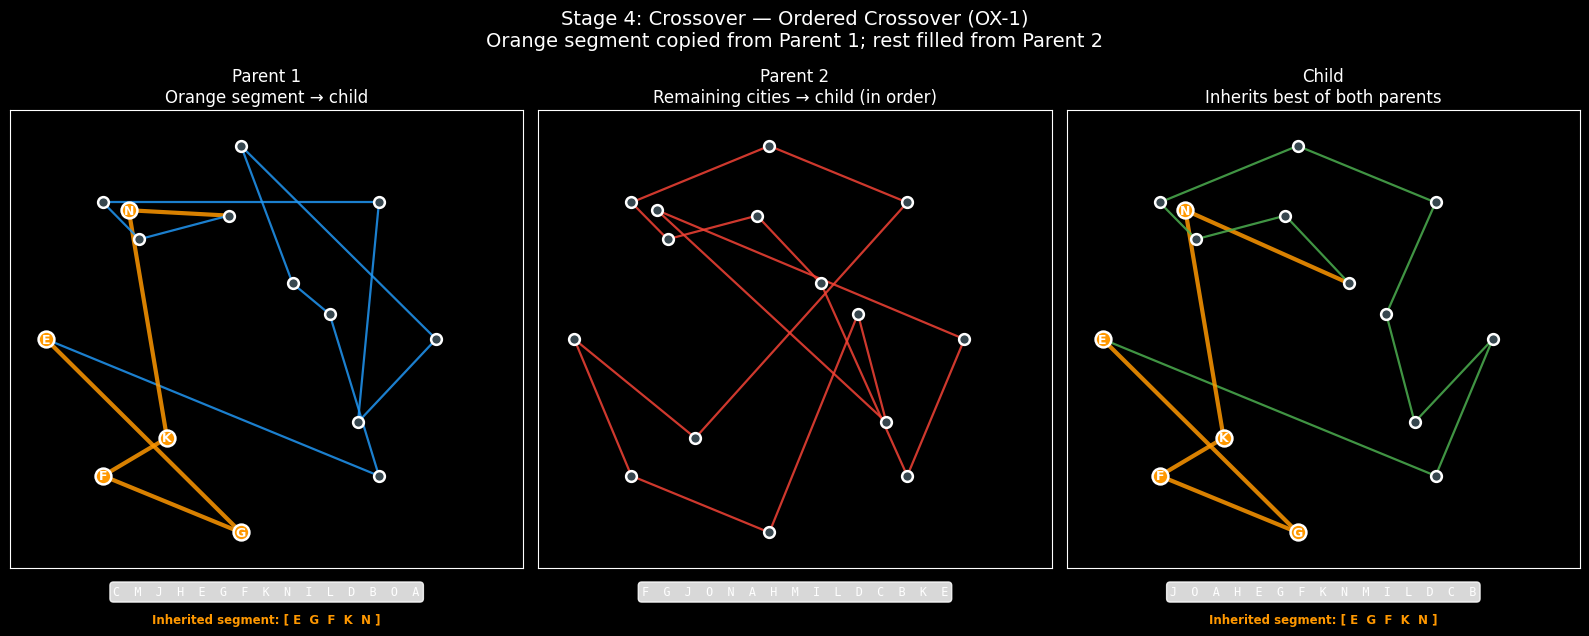

Parent 1 distance: 505
Parent 2 distance: 520
Child distance:    450


In [17]:
random.seed(SEED)
# Use two reasonably good routes for a clear demo
sorted_pop = sorted(range(len(population)),
                    key=lambda i: distances_init[i])
p1 = population[sorted_pop[0]][:]   # best
p2 = population[sorted_pop[2]][:]   # third best

# Fixed crossover window for clarity
CX_A, CX_B = 4, 9

# Perform OX manually so we can highlight
child = [None] * NUM_CITIES
child[CX_A:CX_B] = p1[CX_A:CX_B]
remaining = [c for c in p2 if c not in child[CX_A:CX_B]]
j = 0
for i in range(NUM_CITIES):
    if child[i] is None:
        child[i] = remaining[j];  j += 1

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

def draw_route_cx(ax, route, base_color, title,
                  seg_start=None, seg_end=None, seg_color=ORANGE):
    """Draw route; highlight crossover segment in seg_color."""
    n = len(route)
    for i in range(n):
        a, b  = cities[route[i]], cities[route[(i + 1) % n]]
        in_cx = (seg_start is not None) and (seg_start <= i < seg_end)
        c  = seg_color if in_cx else base_color
        lw = 3.0       if in_cx else 1.6
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=c, alpha=0.85, linewidth=lw, solid_capstyle='round')

    for k in range(n):
        x, y   = cities[k]
        in_cx  = (seg_start is not None and k in route[seg_start:seg_end])
        fc     = seg_color if in_cx else DARK
        size   = 130       if in_cx else 60
        ax.scatter(x, y, s=size, c=fc, zorder=5,
                   edgecolors='white', linewidth=1.8)
        if in_cx:
            ax.annotate(CITY_LABELS[k], (x, y),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white', zorder=6)

    ax.set_title(title, fontsize=12);
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

draw_route_cx(axes[0], p1, BLUE,
              f'Parent 1\nOrange segment → child',
              seg_start=CX_A, seg_end=CX_B)

draw_route_cx(axes[1], p2, RED,
              f'Parent 2\nRemaining cities → child (in order)',
              seg_start=None,  seg_end=None)

draw_route_cx(axes[2], child, GREEN,
              f'Child\nInherits best of both parents',
              seg_start=CX_A, seg_end=CX_B)

# Chromosome bar beneath each panel
for ax, route in zip(axes, [p1, p2, child]):
    label = '  '.join([CITY_LABELS[c] for c in route])
    ax.text(0.5, -0.06, label, transform=ax.transAxes,
            ha='center', fontsize=8.5, fontfamily='monospace',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

# Highlight orange segment in bars 0 and 2
for ax_i, route_i in [(0, 0), (2, 1)]:
    segs = '  '.join([CITY_LABELS[c] for c in [p1, child][route_i][CX_A:CX_B]])
    axes[ax_i].text(0.5, -0.12,
                    f'Inherited segment: [ {segs} ]',
                    transform=axes[ax_i].transAxes,
                    ha='center', fontsize=8.5, color=ORANGE,
                    fontweight='bold')

fig.suptitle('Stage 4: Crossover — Ordered Crossover (OX-1)\n'
             'Orange segment copied from Parent 1; rest filled from Parent 2',
             fontsize=14)
plt.tight_layout()
plt.savefig('05_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Parent 1 distance: {total_distance(p1, cities):.0f}')
print(f'Parent 2 distance: {total_distance(p2, cities):.0f}')
print(f'Child distance:    {total_distance(child, cities):.0f}')


## Stage 5️⃣ — Mutation: Adding a Little Randomness

Without mutation the population would quickly converge on a local optimum
and stop improving. Mutation **occasionally tweaks** a route to introduce
fresh genetic material.

We use **Swap Mutation**: with a small probability (~1.5%), two cities in the
route swap positions. This keeps the route valid while exploring new possibilities.

> Too much mutation → random search (no learning)
> Too little mutation → premature convergence (stuck in local optima)
> ~1–3% is usually the sweet spot.


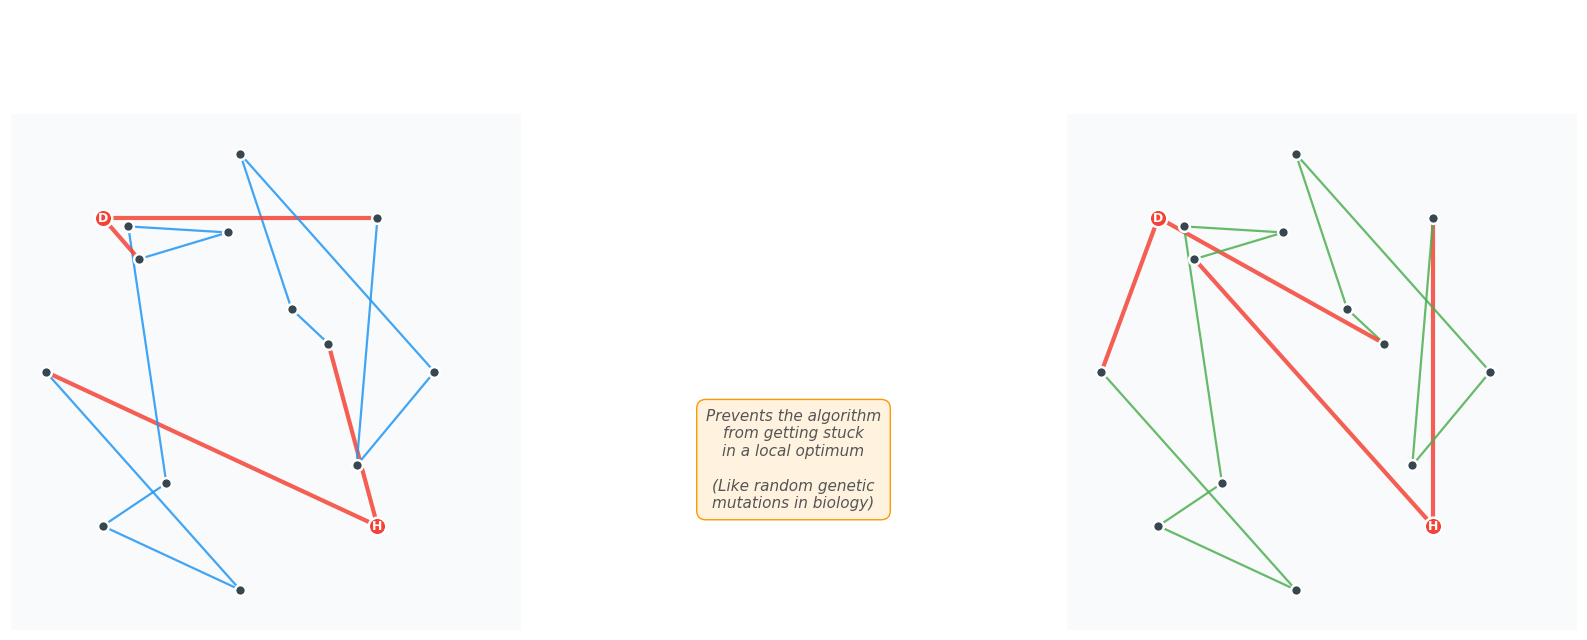

In [12]:
# Pick a decent route and apply one deliberate swap for the demo
demo_route = population[sorted_pop[0]][:]   # best so far
mutated    = demo_route[:]

# Swap positions 3 and 11 for visibility
MI, MJ = 3, 11
mutated[MI], mutated[MJ] = mutated[MJ], mutated[MI]
swapped_cities = {demo_route[MI], demo_route[MJ]}

fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

def draw_route_mut(ax, route, color, title, highlight=None):
    n = len(route)
    for i in range(n):
        a, b   = cities[route[i]], cities[route[(i + 1) % n]]
        in_mut = highlight and (route[i] in highlight or route[(i+1)%n] in highlight)
        c  = RED  if in_mut else color
        lw = 3.0  if in_mut else 1.6
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=c, alpha=0.85, linewidth=lw, solid_capstyle='round')
    for k in range(NUM_CITIES):
        x, y  = cities[k]
        in_hl = highlight and k in highlight
        fc    = RED  if in_hl else DARK
        sz    = 160  if in_hl else 60
        ax.scatter(x, y, s=sz, c=fc, zorder=5, edgecolors='white', linewidth=1.8)
        if in_hl:
            ax.annotate(CITY_LABELS[k], (x, y),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white', zorder=6)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

draw_route_mut(axes[0], demo_route, BLUE,
               f'Before Mutation\nDist: {total_distance(demo_route, cities):.0f}',
               highlight=swapped_cities)

# Middle: explanation panel
axes[1].axis('off')
axes[1].text(0.5, 0.80, '🔀  Mutation!', ha='center', fontsize=18,
             fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.5, 0.58,
             f'Cities  {CITY_LABELS[demo_route[MI]]}  and  '
             f'{CITY_LABELS[demo_route[MJ]]}\nswap positions in the route',
             ha='center', va='center', fontsize=13,
             transform=axes[1].transAxes)
axes[1].text(0.5, 0.33,
             'Prevents the algorithm\nfrom getting stuck\nin a local optimum\n\n'
             '(Like random genetic\nmutations in biology)',
             ha='center', va='center', fontsize=11, style='italic',
             color='#555', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round,pad=0.6', fc='#FFF3E0', ec=ORANGE))
axes[1].text(0.5, 0.08, 'Mutation rate: 1.5%', ha='center', fontsize=11,
             fontweight='bold', transform=axes[1].transAxes)

draw_route_mut(axes[2], mutated, GREEN,
               f'After Mutation\nDist: {total_distance(mutated, cities):.0f}',
               highlight=swapped_cities)

fig.suptitle('Stage 5: Mutation — Swap Mutation\n'
             'A small random change to maintain diversity',
             fontsize=14)
plt.tight_layout()
plt.savefig('06_mutation.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔁 Putting It All Together: Running the Genetic Algorithm

Now we combine all five stages into a loop.
Each pass through the loop is one **generation**.

```
REPEAT for 300 generations:
  1. Score every route  (fitness evaluation)
  2. Keep the top 15   (elitism — don't lose great solutions!)
  3. Fill the rest via  tournament → crossover → mutation
```

Let's run it and watch the population evolve!


In [13]:
SNAP_GENS = [0, 50, 150, 299]

random.seed(SEED);  np.random.seed(SEED)

print('🧬  Running Genetic Algorithm ...')
print('   Population : 150 routes')
print('   Generations: 300')
print('   Mutation   : 1.5 %')
print('   Elite size : 15  (preserved each generation)')
print()

best_route, history, snapshots = run_ga(
    cities,
    pop_size       = 150,
    generations    = 300,
    mutation_rate  = 0.015,
    tournament_k   = 5,
    elite_size     = 15,
    snapshot_gens  = SNAP_GENS,
)

initial_d   = history['best_distances'][0]
final_d     = history['best_distances'][-1]
improvement = (1 - final_d / initial_d) * 100

print('✅  Done!')
print(f'   Initial best distance : {initial_d:.1f}')
print(f'   Final best distance   : {final_d:.1f}')
print(f'   Improvement           : {improvement:.1f} %')


🧬  Running Genetic Algorithm ...
   Population : 150 routes
   Generations: 300
   Mutation   : 1.5 %
   Elite size : 15  (preserved each generation)

✅  Done!
   Initial best distance : 505.2
   Final best distance   : 285.1
   Improvement           : 43.6 %


## 📈  Evolution Progress: Distance Over Generations

Watch the best and average distances drop as the population evolves.
Early generations improve quickly; later generations refine fine details.


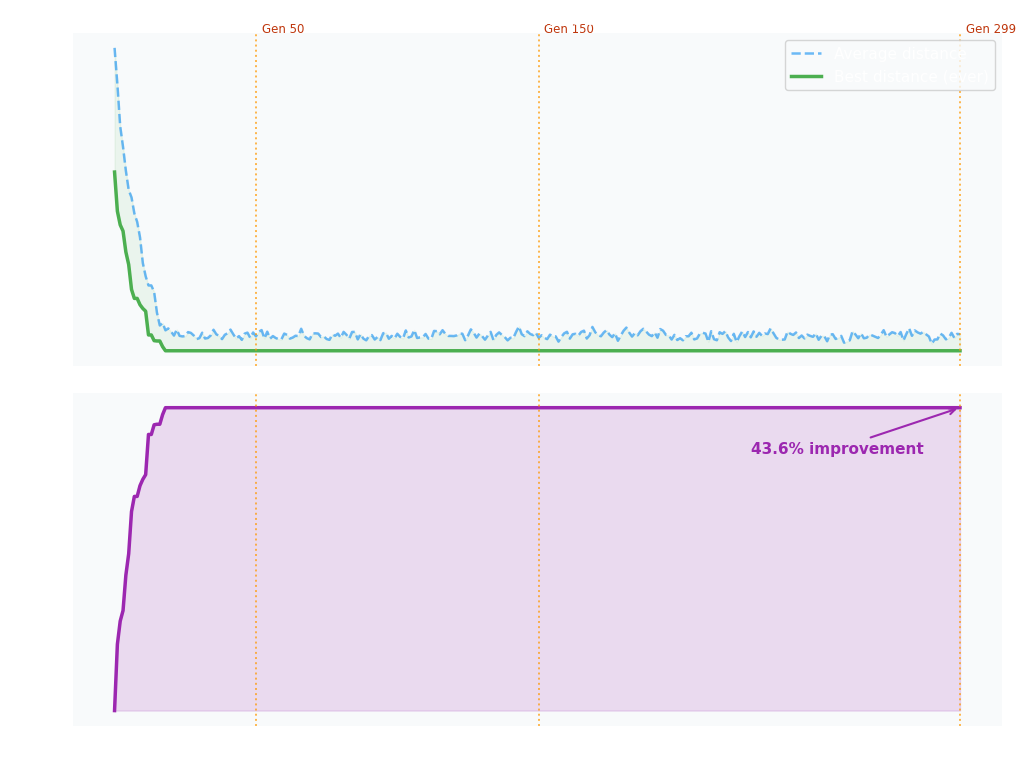

In [14]:
gens = range(len(history['best_distances']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# ── Top: Distance curves ─────────────────────────────────────────────────────
ax1.plot(gens, history['avg_distances'],  color=BLUE,   linewidth=1.8,
         alpha=0.65, linestyle='--', label='Average distance')
ax1.plot(gens, history['best_distances'], color=GREEN,  linewidth=2.5,
         label='Best distance (ever)')
ax1.fill_between(gens,
                 history['best_distances'],
                 history['avg_distances'],
                 alpha=0.08, color=GREEN)

for sg in SNAP_GENS[1:]:
    ax1.axvline(sg, color=ORANGE, linestyle=':', alpha=0.7, linewidth=1.4)
    ax1.text(sg + 2, ax1.get_ylim()[1] if ax1.get_ylim()[1] else
             max(history['avg_distances']) * 0.98,
             f'Gen {sg}', fontsize=8.5, color='#BF360C')

ax1.set_ylabel('Total Route Distance', fontsize=12)
ax1.set_title('Genetic Algorithm Convergence', fontsize=14)
ax1.legend(fontsize=11)

# ── Bottom: Cumulative improvement % ─────────────────────────────────────────
best_arr = np.array(history['best_distances'])
pct      = (best_arr[0] - best_arr) / best_arr[0] * 100

ax2.plot(gens, pct, color=PURPLE, linewidth=2.5)
ax2.fill_between(gens, pct, alpha=0.15, color=PURPLE)

for sg in SNAP_GENS[1:]:
    ax2.axvline(sg, color=ORANGE, linestyle=':', alpha=0.7, linewidth=1.4)

# Annotate final improvement
ax2.annotate(f'{pct[-1]:.1f}% improvement',
             xy=(len(gens) - 1, pct[-1]),
             xytext=(len(gens) * 0.75, pct[-1] * 0.85),
             fontsize=11, color=PURPLE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.5))

ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Improvement over Gen 0 (%)', fontsize=12)
ax2.set_title('Cumulative Improvement', fontsize=14)

plt.tight_layout()
plt.savefig('07_fitness_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 🗺️  Route Evolution: Snapshots Across Generations

See how the route transforms from a tangled mess into an efficient path.


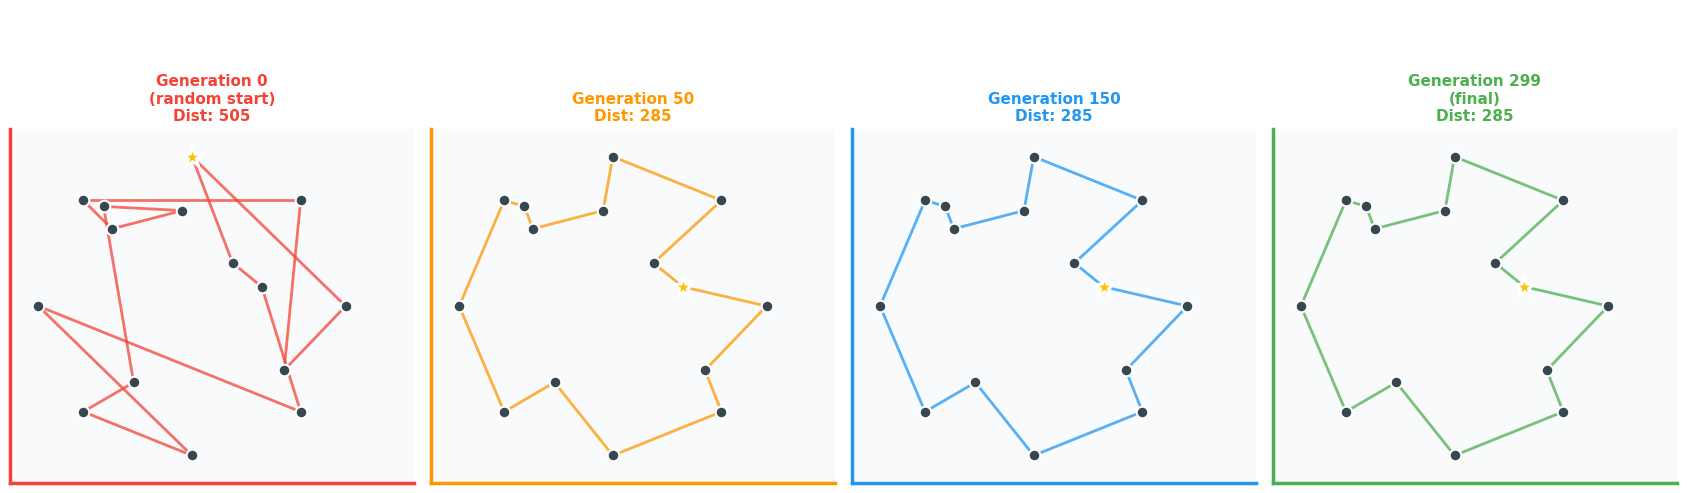

In [15]:
snap_labels = ['Generation 0\n(random start)',
               'Generation 50',
               'Generation 150',
               'Generation 299\n(final)']
snap_colors = [RED, ORANGE, BLUE, GREEN]

fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, gen, label, color in zip(axes, SNAP_GENS, snap_labels, snap_colors):
    route = snapshots.get(gen, best_route)
    dist  = total_distance(route, cities)
    n     = len(route)

    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=0.75, linewidth=2.0, solid_capstyle='round')

    ax.scatter(cities[:, 0], cities[:, 1],
               s=70, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)
    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=220, c=GOLD, zorder=6,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'{label}\nDist: {dist:.0f}', fontsize=11, color=color)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color);  spine.set_linewidth(2.5)

fig.suptitle('Route Evolution Over 300 Generations\n'
             '★ = Starting City   |   Routes become smoother as generations pass',
             fontsize=14)
plt.tight_layout()
plt.savefig('08_route_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏆  Final Result: The Evolved Solution

Let's compare the initial random solution against what the GA discovered.


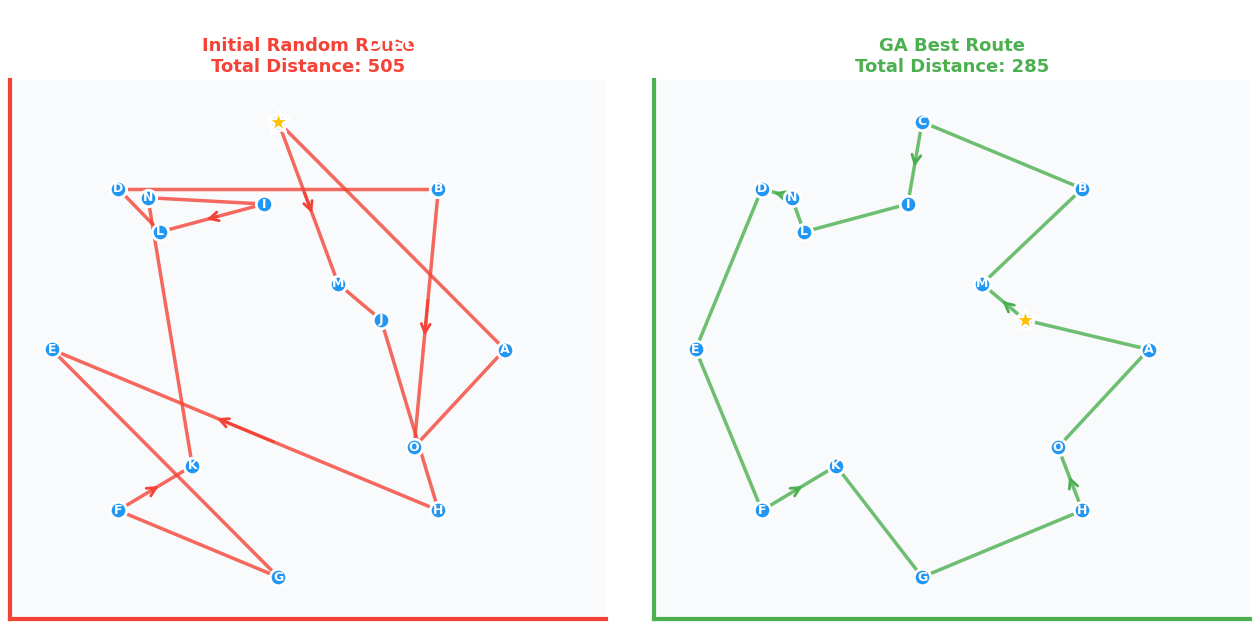


  SUMMARY
  Cities          : 15
  Population      : 150 routes
  Generations     : 300
  Mutation rate   : 1.5 %
  Elite size      : 15
  Initial dist    : 505.2
  Final dist      : 285.1
  Improvement     : 43.6 %


In [16]:
fig = plt.figure(figsize=(16, 7))
gs  = GridSpec(1, 2, figure=fig, wspace=0.08)

init_route = snapshots.get(0, population[0])
init_dist  = total_distance(init_route, cities)
final_dist = total_distance(best_route, cities)

for col, (route, dist, color, tag) in enumerate([
        (init_route, init_dist, RED,   'Initial Random Route'),
        (best_route, final_dist, GREEN, 'GA Best Route')]):

    ax = fig.add_subplot(gs[col])
    n  = len(route)

    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=0.8, linewidth=2.5, solid_capstyle='round')

    # Direction arrows
    for i in range(0, n, 3):
        a, b   = cities[route[i]], cities[route[(i + 1) % n]]
        mid    = (a + b) / 2
        delta  = (b - a) * 0.08
        ax.annotate('', xy=mid + delta, xytext=mid - delta,
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=2, mutation_scale=16))

    ax.scatter(cities[:, 0], cities[:, 1],
               s=140, c=BLUE, zorder=5, edgecolors='white', linewidth=2)
    for i, (x, y) in enumerate(cities):
        ax.annotate(CITY_LABELS[i], (x, y),
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white', zorder=6)

    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=300, c=GOLD, zorder=7,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'{tag}\nTotal Distance: {dist:.0f}', fontsize=13, color=color)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color);  spine.set_linewidth(3)

improvement = (1 - final_dist / init_dist) * 100
fig.suptitle(f'Genetic Algorithm Result\n'
             f'Distance reduced by {improvement:.1f}%  '
             f'({init_dist:.0f}  →  {final_dist:.0f})',
             fontsize=15, fontweight='bold')
plt.savefig('09_final_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"=" * 45}')
print(f'  SUMMARY')
print(f'{"=" * 45}')
print(f'  Cities          : {NUM_CITIES}')
print(f'  Population      : 150 routes')
print(f'  Generations     : 300')
print(f'  Mutation rate   : 1.5 %')
print(f'  Elite size      : 15')
print(f'  Initial dist    : {init_dist:.1f}')
print(f'  Final dist      : {final_dist:.1f}')
print(f'  Improvement     : {improvement:.1f} %')
print(f'{"=" * 45}')


## ✅  Key Takeaways

### Why Genetic Algorithms Work
| Mechanism | Purpose |
|---|---|
| **Large population** | Explore many solutions simultaneously |
| **Fitness evaluation** | Steer search toward better solutions |
| **Selection pressure** | Better solutions reproduce more often |
| **Crossover** | Combine good "building blocks" from parents |
| **Mutation** | Escape local optima; maintain diversity |
| **Elitism** | Never lose the best solution found |

### When to Use Genetic Algorithms
- The search space is **huge** (can't brute-force)
- The fitness function can be **evaluated** even if it can't be differentiated
- You need a **good-enough** solution, not necessarily the perfect one
- Examples: scheduling, circuit layout, neural architecture search, game AI, protein folding

### Limitations
- **Not guaranteed** to find the global optimum
- **Computationally expensive** (many evaluations per generation)
- Results depend heavily on **hyperparameter tuning** (population size, mutation rate, etc.)
- Can still **get stuck** in local optima if diversity collapses

---

### Further Exploration
- Try changing `NUM_CITIES`, `pop_size`, `mutation_rate`, or `generations`
- Swap the fitness function to solve a different optimisation problem
- Implement **two-point crossover** or **inversion mutation** and compare

> *"It is not the strongest of the species that survives, nor the most intelligent,
>  but the one most responsive to change."*  — often attributed to Darwin
